In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [17]:
os.environ["LOKY_MAX_CPU_COUNT"] = '14'
os.environ["OMP_NUM_THREADS"] = "1"

In [3]:
bronze = pd.read_csv("processed_csvs/bronze.csv")
champion = pd.read_csv("processed_csvs/champion.csv")
diamond = pd.read_csv("processed_csvs/diamond.csv")
gold = pd.read_csv("processed_csvs/gold.csv")
grand = pd.read_csv("processed_csvs/grand.csv")
platinum = pd.read_csv("processed_csvs/platinum.csv")
silver = pd.read_csv("processed_csvs/silver.csv")
supersonic = pd.read_csv("processed_csvs/supersonic.csv")

ranks = {"Bronze": bronze, "Champion": champion, "Diamond": diamond, "Gold": gold, "Grandmaster": grand, 
         "Platinum": platinum, "Silver": silver, "Supersonic": supersonic}

In [4]:
ranks['Bronze'].columns

Index(['color', 'player name', 'platform', 'player id', 'car id', 'car name',
       'game duration', 'score', 'goals', 'assists', 'saves', 'shots',
       'shots conceded', 'goals conceded',
       'goals conceded while last defender', 'shooting percentage', 'bpm',
       'avg boost amount', 'amount collected', 'amount collected big pads',
       'amount collected small pads', 'count collected big pads',
       'count collected small pads', 'amount stolen', 'amount stolen big pads',
       'amount stolen small pads', 'count stolen big pads',
       'count stolen small pads', '0 boost time', '100 boost time',
       'amount used while supersonic', 'amount overfill total',
       'amount overfill stolen', 'avg speed', 'total distance',
       'time slow speed', 'percentage slow speed', 'time boost speed',
       'percentage boost speed', 'time supersonic speed',
       'percentage supersonic speed', 'time on ground', 'percentage on ground',
       'time low in air', 'percentage low in a

In [5]:
for rank, df in ranks.items():
    ranks[rank] = df.dropna()

rank_sne = {}

for rank, df in ranks.items():
    temp = df.drop(columns=[
    'color','player name','platform','player id','car id','car name','rank'])
    rank_sne[rank] = temp

for rank, df in rank_sne.items():
    check = df.var().sort_values()
    for j in check.index:
        if check[j] == 0:
            print(j)

for rank, df in rank_sne.items():
    print(df.isna().sum().sort_values())

game duration                 0
score                         0
goals                         0
assists                       0
saves                         0
                             ..
percentage neutral third      0
time offensive third          0
percentage offensive third    0
demos inflicted               0
demos taken                   0
Length: 66, dtype: int64
game duration                 0
score                         0
goals                         0
assists                       0
saves                         0
                             ..
percentage neutral third      0
time offensive third          0
percentage offensive third    0
demos inflicted               0
demos taken                   0
Length: 66, dtype: int64
game duration                 0
score                         0
goals                         0
assists                       0
saves                         0
                             ..
percentage neutral third      0
time offensive third  

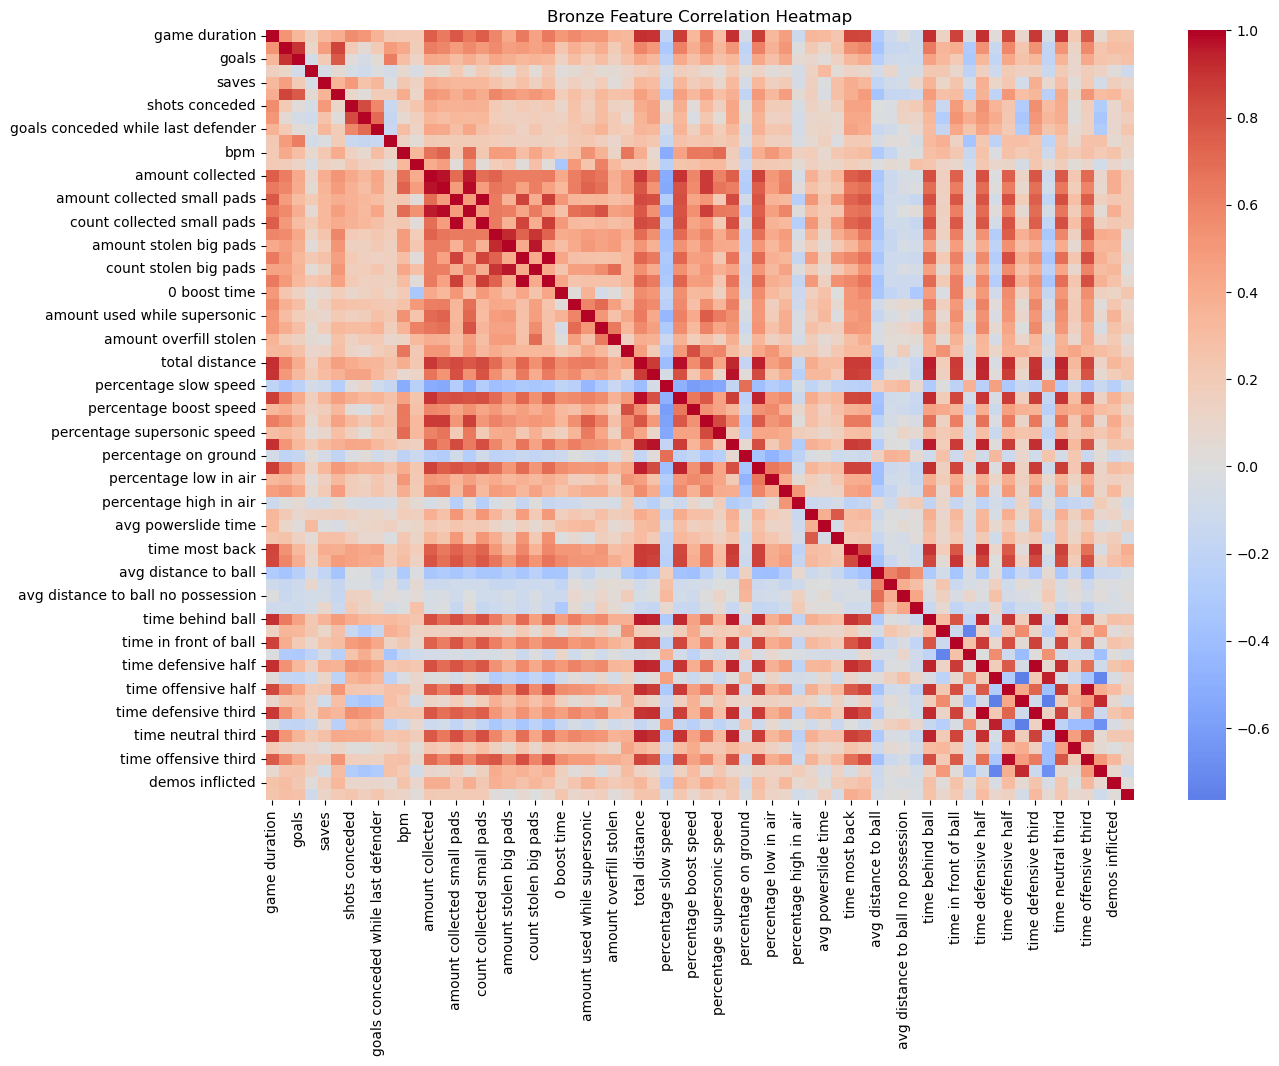

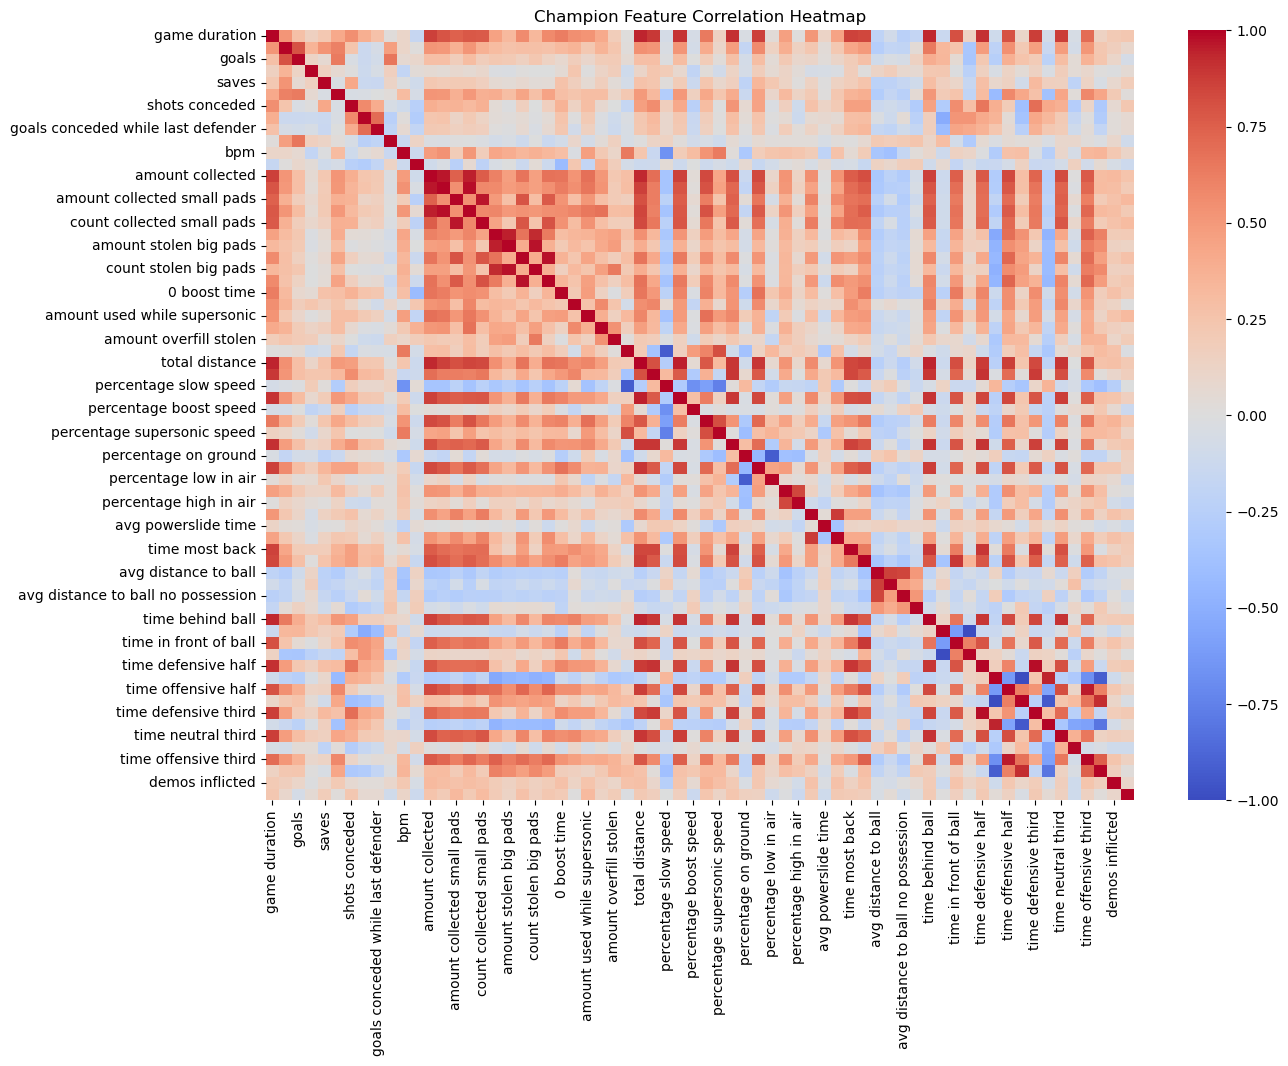

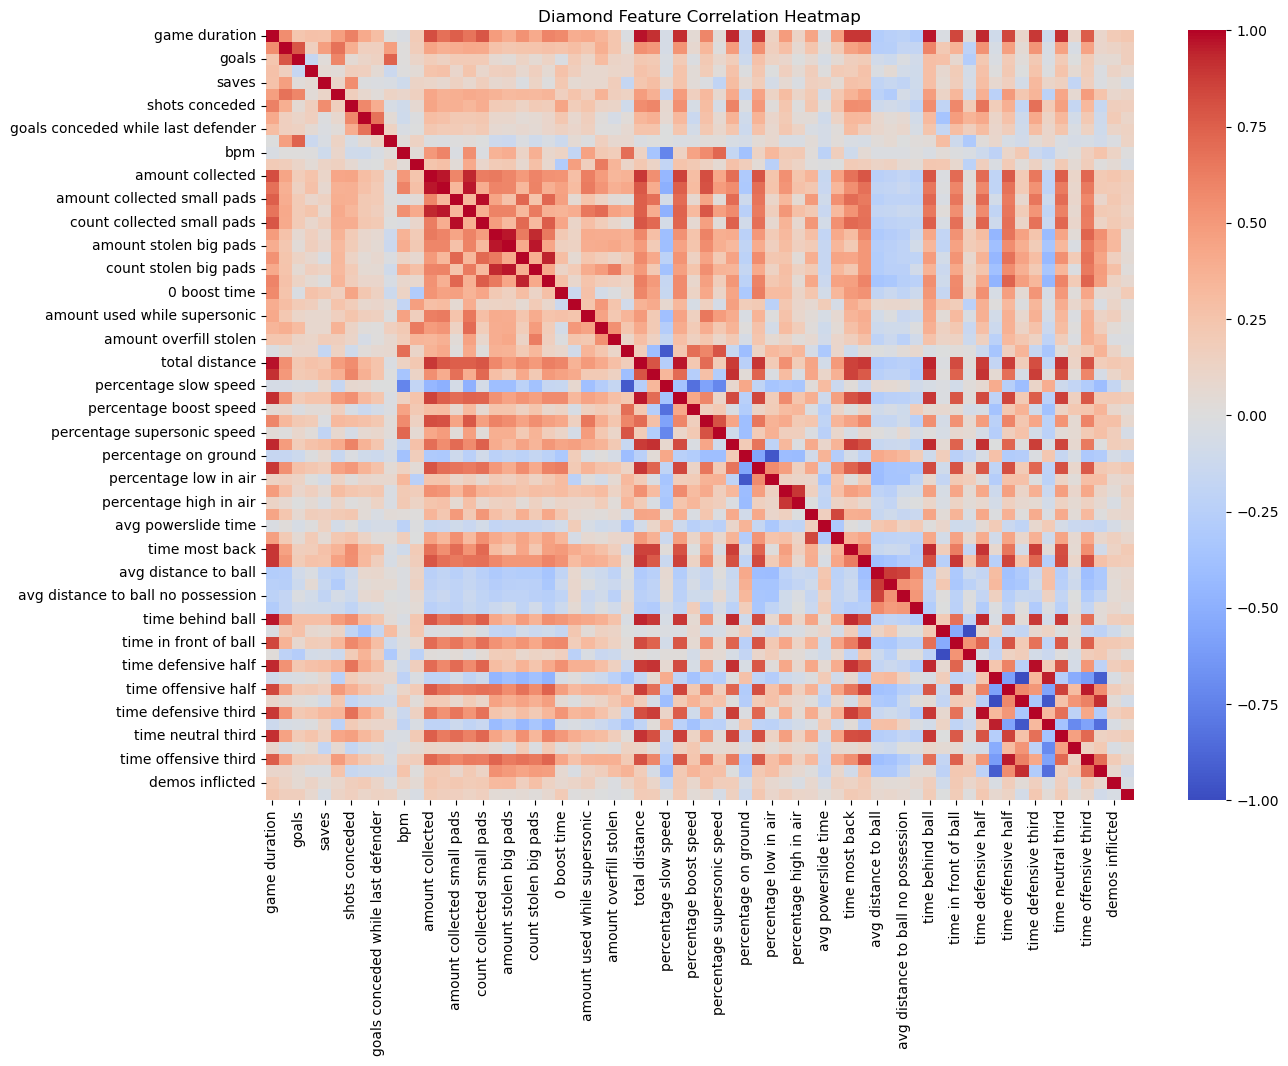

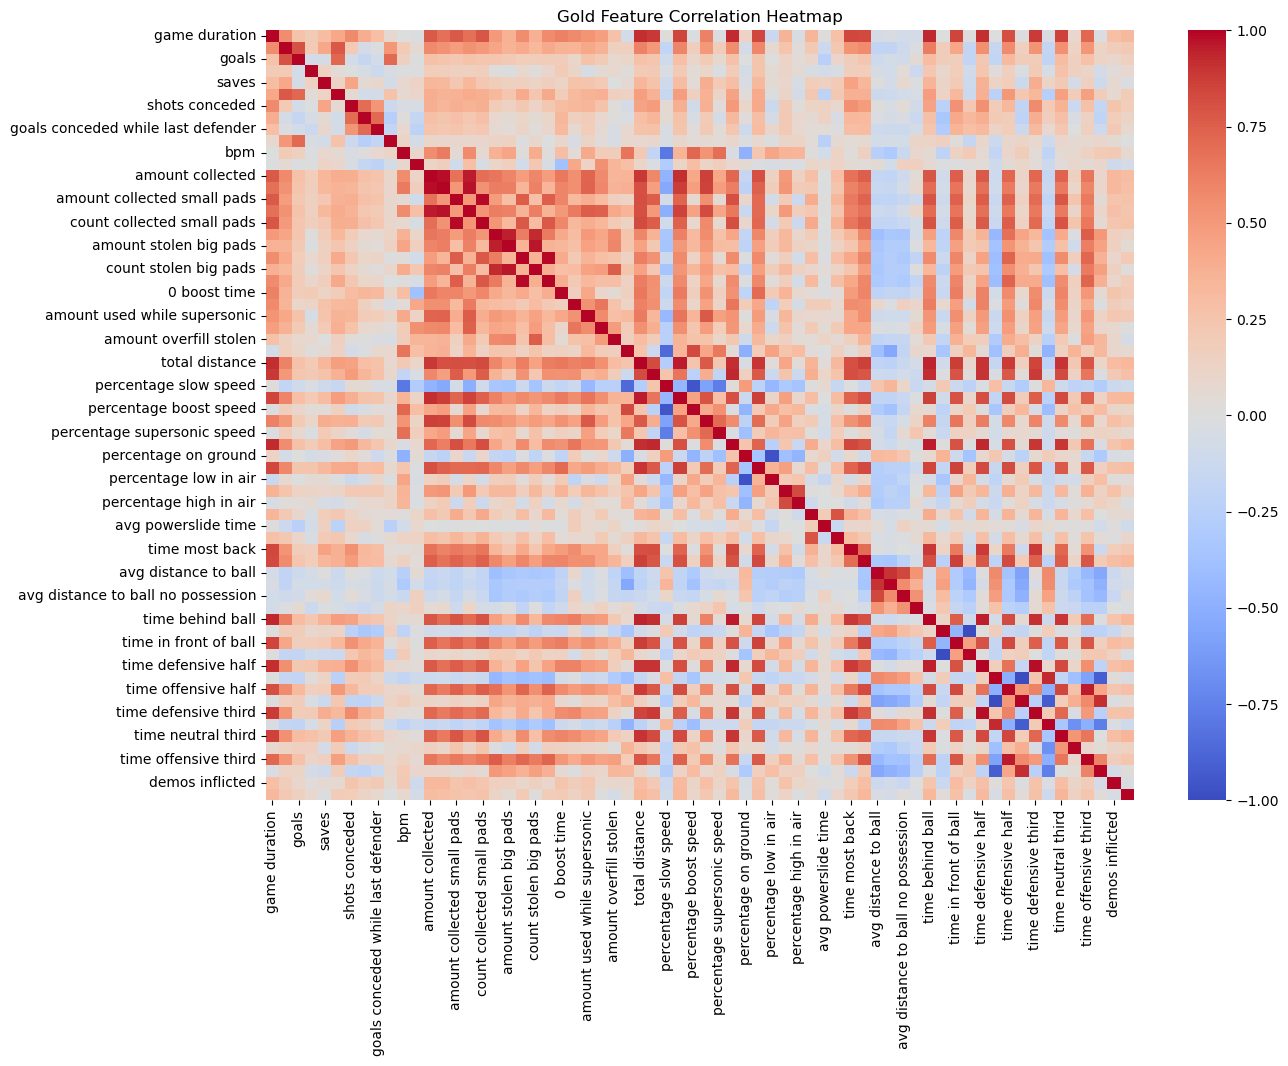

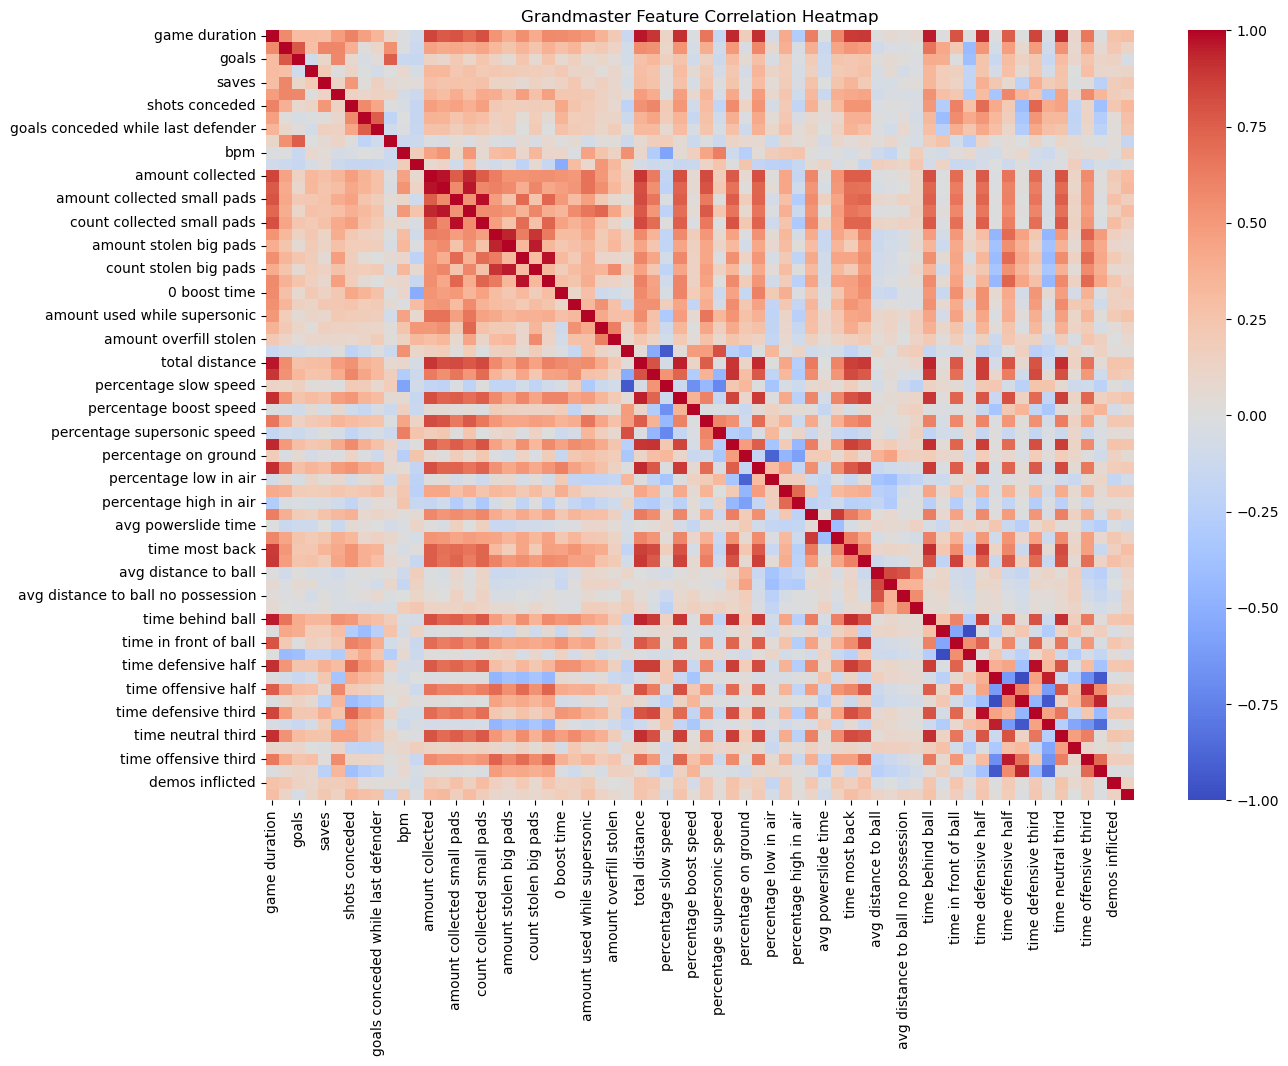

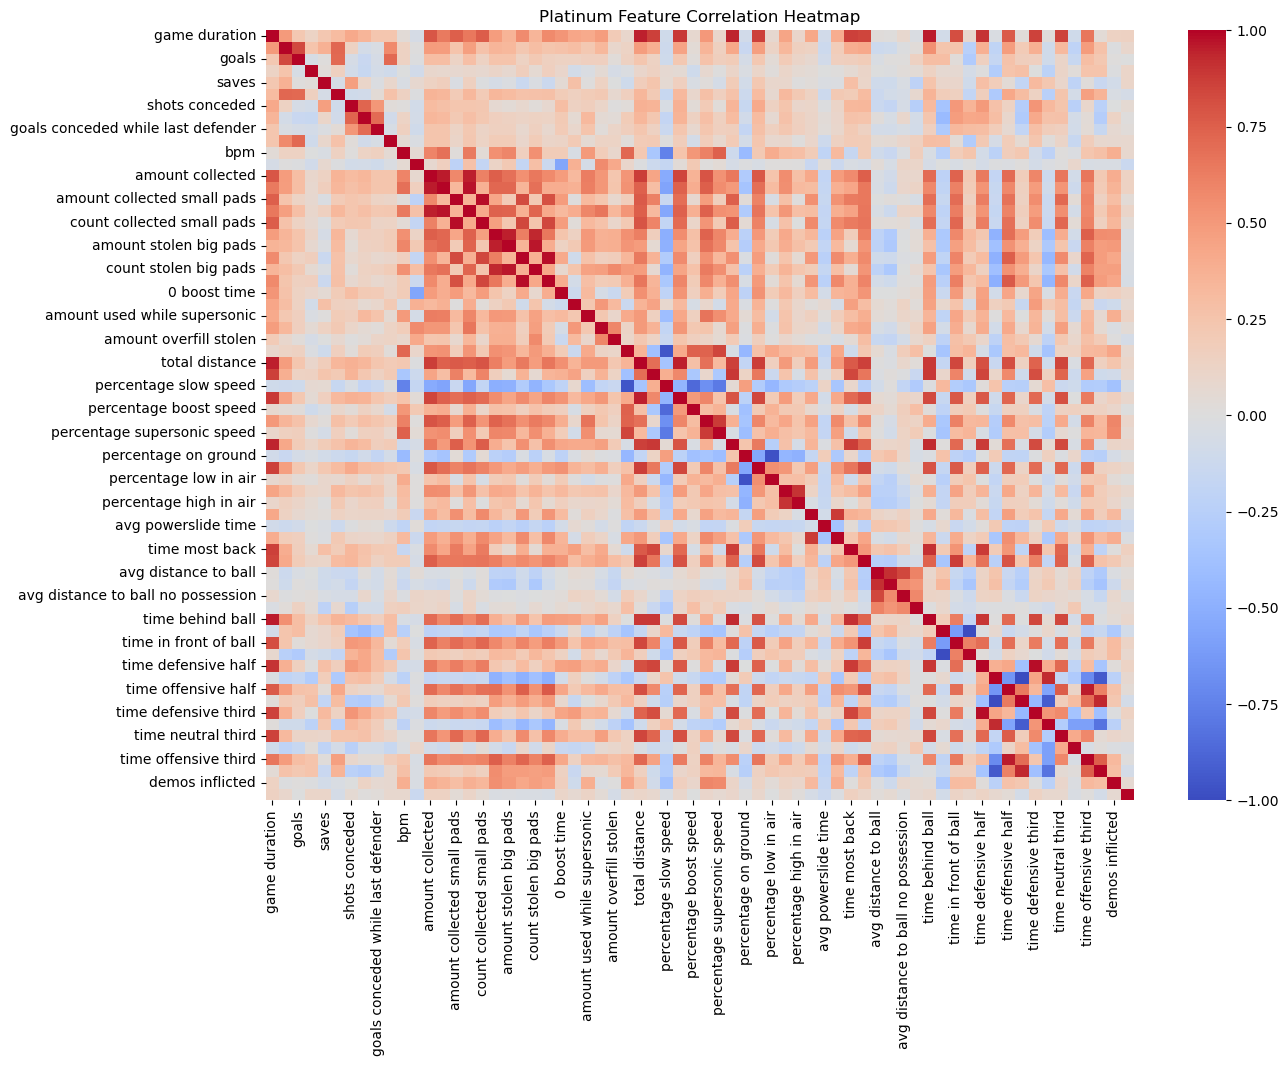

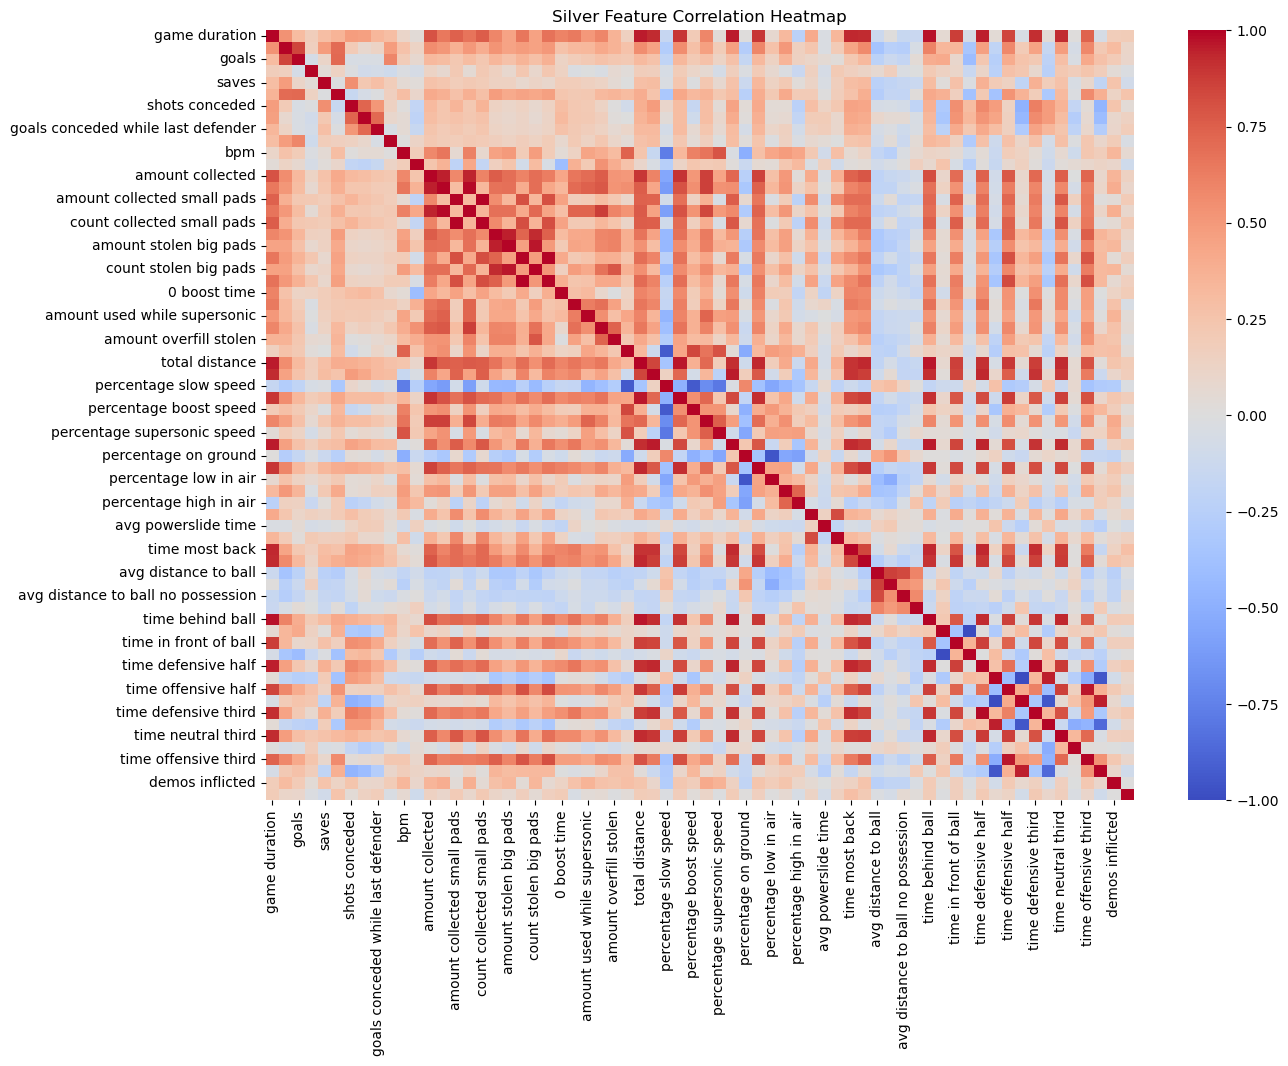

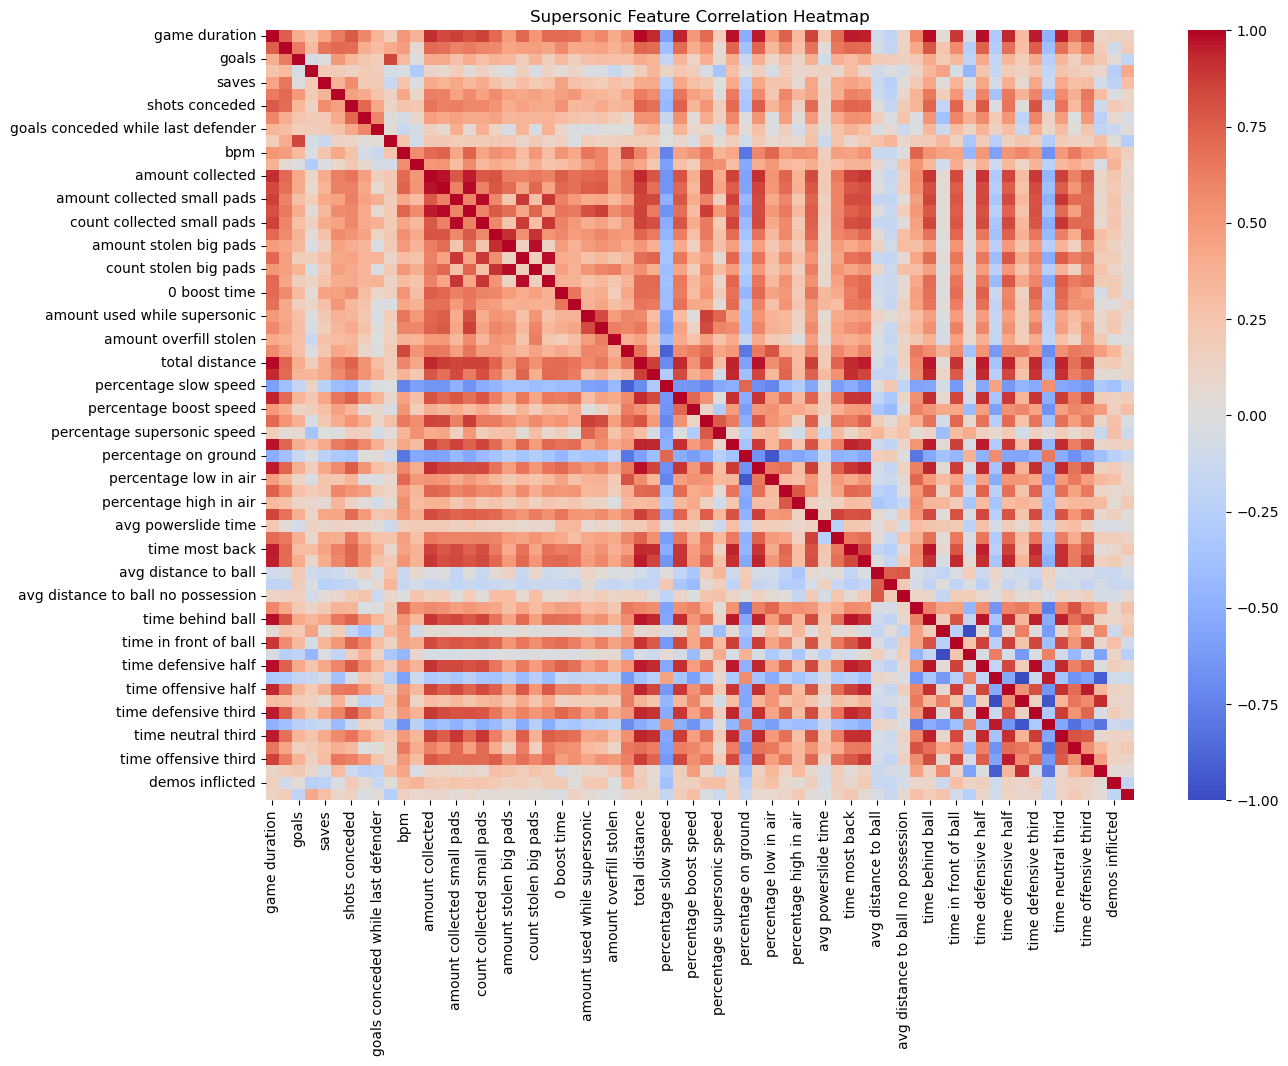

In [6]:
for rank, df in rank_sne.items():
    corr = df.select_dtypes(include='number').corr()
    
    plt.figure(figsize=(14,10))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title(f"{rank} Feature Correlation Heatmap")
    plt.show()

1 components: 0.3845
2 components: 0.4802
3 components: 0.5505
4 components: 0.6011
5 components: 0.6391
6 components: 0.6754
7 components: 0.7099
8 components: 0.7413
9 components: 0.7674
10 components: 0.7898
11 components: 0.8098
12 components: 0.8275
13 components: 0.8440
14 components: 0.8591
15 components: 0.8725
16 components: 0.8841
17 components: 0.8955
18 components: 0.9061
19 components: 0.9158
20 components: 0.9252
21 components: 0.9330
22 components: 0.9404
23 components: 0.9475
24 components: 0.9544
25 components: 0.9600
26 components: 0.9653
27 components: 0.9700
28 components: 0.9740
29 components: 0.9772
30 components: 0.9801
31 components: 0.9825
32 components: 0.9848
33 components: 0.9867
34 components: 0.9883
35 components: 0.9898
36 components: 0.9912
37 components: 0.9924
38 components: 0.9936
39 components: 0.9946
40 components: 0.9956
41 components: 0.9964
42 components: 0.9971
43 components: 0.9977
44 components: 0.9982
45 components: 0.9986
46 components: 0.99

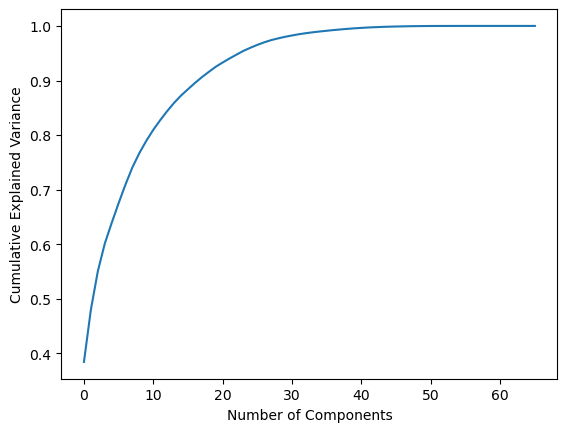

In [7]:
scaler = StandardScaler()
rank_scaled = scaler.fit_transform(rank_sne['Bronze'])

pca = PCA()
pca.fit(rank_scaled)

plt.plot(pca.explained_variance_ratio_.cumsum())
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
cum_var = np.cumsum(pca.explained_variance_ratio_)
for i, val in enumerate(np.cumsum(pca.explained_variance_ratio_), start=1):
    print(f"{i} components: {val:.4f}")

In [11]:
tsne_data = {}

for rank, df in rank_sne.items():
    scaler = StandardScaler()
    rank_scaled = scaler.fit_transform(df)

    rank_pca = PCA(n_components=18).fit_transform(rank_scaled)
    rank_tsne = TSNE(n_components=2, random_state=42).fit_transform(rank_pca)

    tsne_data[rank] = [rank_pca,rank_tsne]

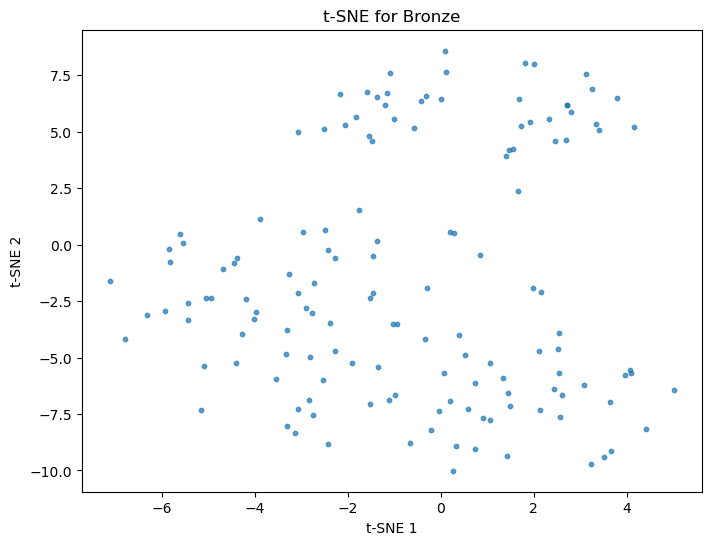

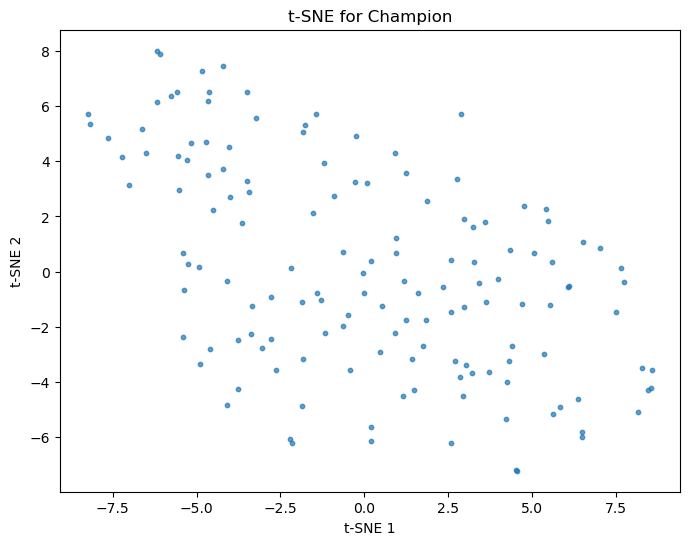

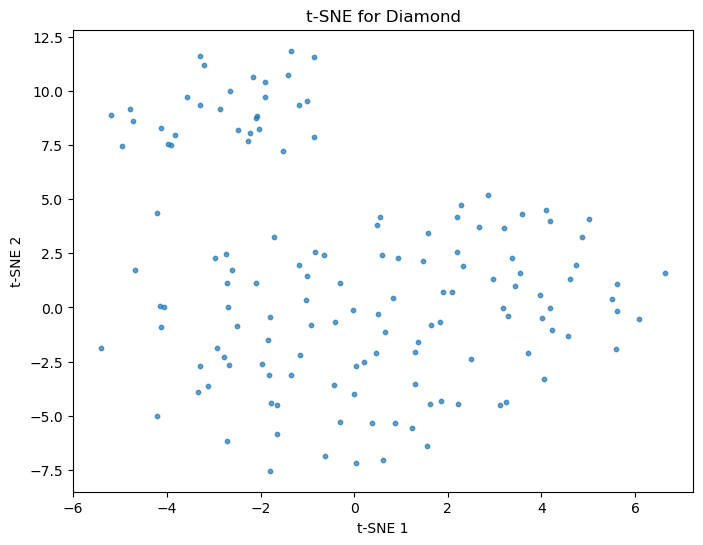

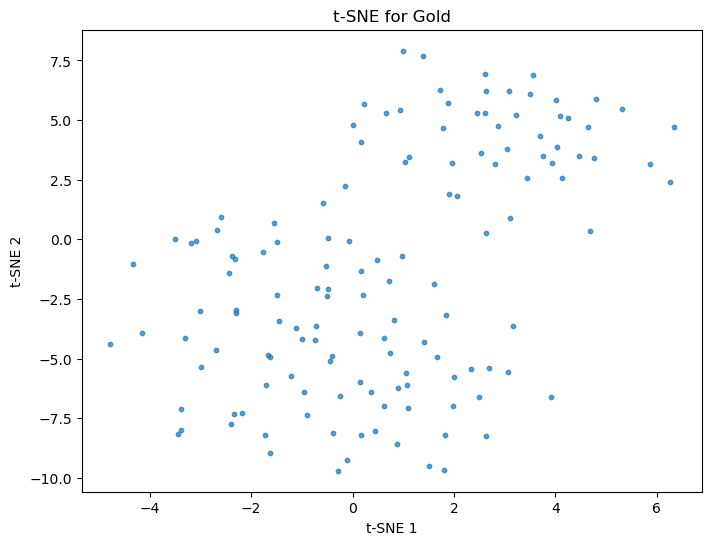

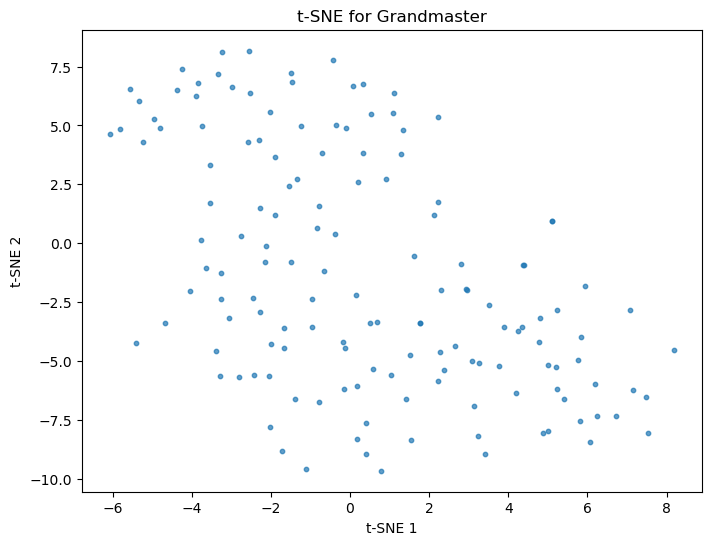

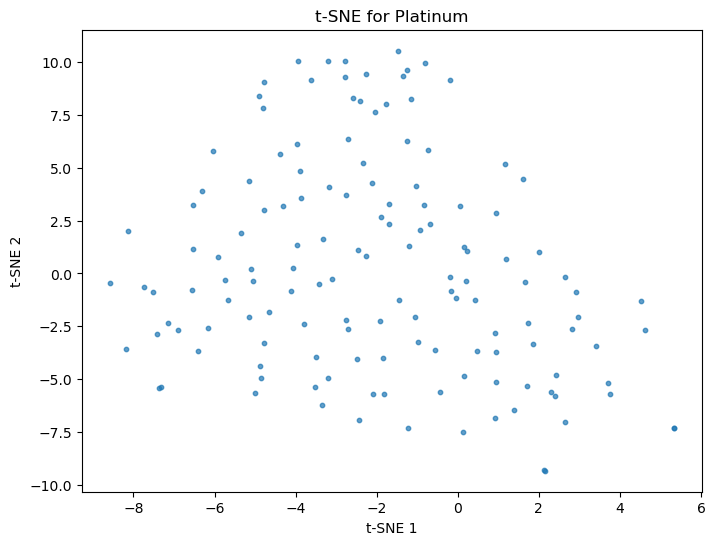

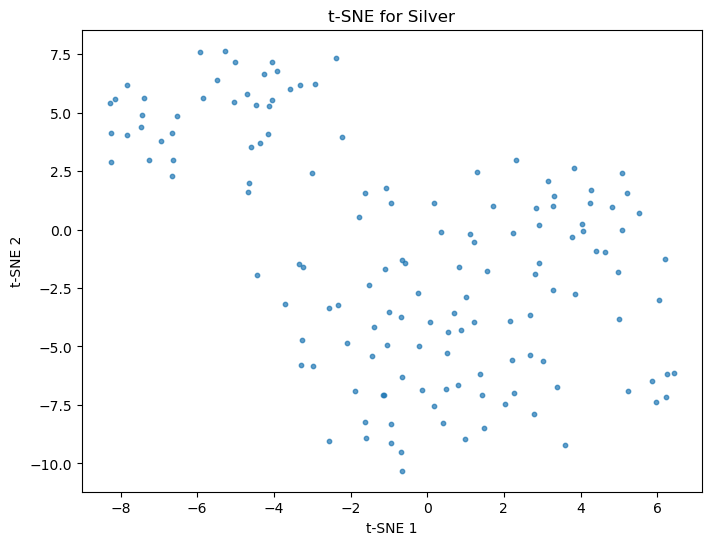

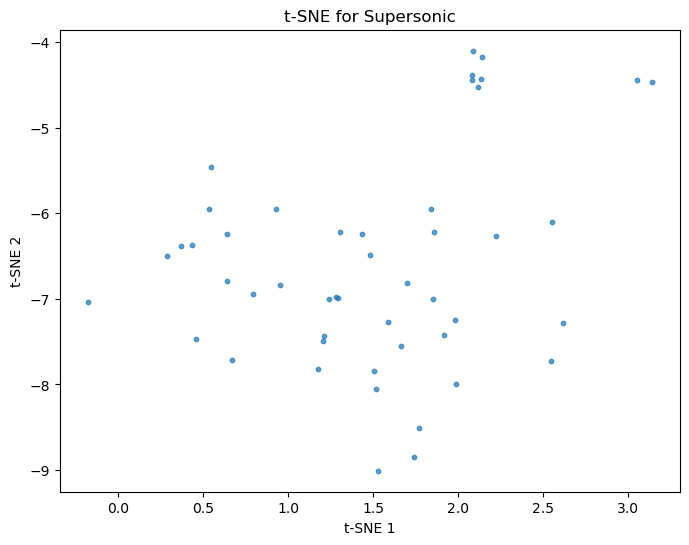

In [12]:
for rank, coords in tsne_data.items():
    plt.figure(figsize=(8, 6))
    plt.scatter(coords[1][:, 0], coords[1][:, 1], s=10, alpha=0.7)
    plt.title(f"t-SNE for {rank}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

In [13]:
for rank, coords, in tsne_data.items():
    
    score = trustworthiness(coords[0], coords[1], n_neighbors=5)
    print(f'{rank} trustworthiness: {score}')

Bronze trustworthiness: 0.9430171172612382
Champion trustworthiness: 0.9361926961926962
Diamond trustworthiness: 0.9420945686199133
Gold trustworthiness: 0.9311465992647059
Grandmaster trustworthiness: 0.928625408496732
Platinum trustworthiness: 0.9302762370256467
Silver trustworthiness: 0.9501787101787101
Supersonic trustworthiness: 0.9045833333333333


In [19]:
for rank, coords, in tsne_data.items():
    labels = KMeans(n_clusters=5).fit_predict(coords[1])
    sil = silhouette_score(coords[1], labels)
    print(f'{rank} silhoutte score: {sil}')

Bronze silhoutte score: 0.41995635628700256
Champion silhoutte score: 0.3715492784976959
Diamond silhoutte score: 0.4333188235759735
Gold silhoutte score: 0.41384780406951904
Grandmaster silhoutte score: 0.3618330657482147
Platinum silhoutte score: 0.39664602279663086
Silver silhoutte score: 0.393887460231781
Supersonic silhoutte score: 0.41485127806663513


C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window